# Aggregate Analysis of HIPPO Data

In [28]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob

In [29]:
# set this up to point to the libararies directory in ml-holodec
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'Optics')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)

In [30]:
import MieLibrary as mie

In [31]:
data_base_path = "/scr/raf/Prod_Data/"


# hippo1_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-1","*.nc"))
# hippo1_loc_tag = "_RWI"

# hippo2_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-2","*.nc"))
# hippo2_loc_tag = "_RWI"

# hippo3_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-3","*.nc"))
# hippo3_loc_tag = "_RWI"

# hippo4_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-4","*.nc"))
# hippo4_loc_tag = "_RWI"

# hippo5_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-5","*.nc"))
# hippo5_loc_tag = "_RWI"

### Projects to use

In [32]:
project_dct = {
    'HIPPO1':{
        "name":"HIPPO-1",
        "sub_folder":"HIPPO-1",
        "loc_tag":"RWI"
    },
    'HIPPO2':{
        "name":"HIPPO-2",
        "sub_folder":"HIPPO-2",
        "loc_tag":"RWI"
    },
    'HIPPO4':{
        "name":"HIPPO-4",
        "sub_folder":"HIPPO-4",
        "loc_tag":"RWI"
    },
    'HIPPO5':{
        "name":"HIPPO-5",
        "sub_folder":"HIPPO-5",
        "loc_tag":"RWI"
    }
}

### Lidar and Model Definitions

In [33]:
wavelen_lst = [1064e-9, 532e-9, 355e-9]  # list of wavelengths
wavelen_color = ['tab:red', 'tab:green','tab:purple'] 

# wavelen_lst = [1064e-9, 532e-9,]  # list of wavelengths
# wavelen_color = ['tab:red', 'tab:green',] 

index_refrac = 1.5  # assumed refractive index of particle

In [35]:
number_conc_lst = []
r_eff_lst = []
mean_r_lst = []
mean_ln_r_lst = []
std_ln_r_lst = []
beta_coef_lst = []
alpha_coef_lst = []
project_label_lst = []

aircraft_vars = ['GGLAT','GGLON','GGALT','Time']
aircraft_vars_dct = {}
for var in aircraft_vars:
    aircraft_vars_dct[var] = []

for proj in project_dct:
    postfix = project_dct[proj]['loc_tag']
    file_lst = glob.glob(os.path.join(data_base_path,project_dct[proj]['sub_folder'],"*.nc"))

    print(project_dct[proj]['name']+f": {len(file_lst)} files")
    
    # postfix = 'RWOOU'  # CSET
    # postfix = 'CVIU'   # SOCRATES
    # postfix = 'RWI'  # HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5
    
    # TODO also read in GGLAT, GGLON, GGALT
    
    # file_lst = cset_lst
    # file_lst = socrates_lst
    # file_lst = hippo1_lst
    # file_lst = hippo2_lst
    # file_lst = hippo4_lst
    # file_lst = hippo5_lst
    
    load_params = True
    
    for fidx,file in enumerate(file_lst):
        ds = xr.open_dataset(file)
        load_file = True
        
        if load_params:
            # run all the initial calculations
            try:
                part_diam = ds['CUHSAS_'+postfix].attrs['CellSizes']*1e-6
                load_params = False
                r_arr = part_diam/2
                ang_arr = np.linspace(0,500e-6,100)
                dang=np.diff(ang_arr)
                solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)
                r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)
        
                sig_pi = np.zeros((len(wavelen_lst),r_arr.size))
                sig_e = np.zeros((len(wavelen_lst),r_arr.size))
                
                for wl_idx, wavelen in enumerate(wavelen_lst):
                    k_num = 2*np.pi/wavelen
                    for r_idx,r_val in enumerate(r_arr):
                        x_val = 2*np.pi*r_val/wavelen
                        Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
                        sig_pi[wl_idx,r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr))
                        sig_e[wl_idx,r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2
            except KeyError:
                load_file = False
    
        # skip loading the data if there is no UHSAS data
        if load_file:
            # dataset calculations
            beta_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
            alpha_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
            for idx in range(len(wavelen_lst)):
                beta_coef[idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_pi[idx,:][np.newaxis,:],axis=1)/solid_angle
                alpha_coef[idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_e[idx,:][np.newaxis,:],axis=1)
            number_conc = np.trapz(ds['CUHSAS_'+postfix].values.squeeze(),axis=1)

            r_eff = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)
            mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
            mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
            std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
        
            valid_idx = np.where(number_conc > 0)  # locate and only use cases where the concentration is > 0
            for var in aircraft_vars_dct:
                aircraft_vars_dct[var].append(ds[var].values[valid_idx[0]])
        
            beta_coef_lst.append(beta_coef[:,valid_idx[0]])
            alpha_coef_lst.append(alpha_coef[:,valid_idx[0]])
            number_conc_lst.append(number_conc[valid_idx[0]])
            r_eff_lst.append(r_eff[valid_idx[0]])
            mean_r_lst.append(mean_r[valid_idx[0]])
            mean_ln_r_lst.append(mean_ln_r[valid_idx[0]])
            std_ln_r_lst.append(std_ln_r[valid_idx[0]])
            project_label_lst.append([project_dct[proj]['name']]*len(valid_idx[0]))

HIPPO-1: 14 files


/tmp/ipykernel_645262/525961653.py:74: RuntimeWarning: invalid value encountered in divide
  r_eff = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)
/tmp/ipykernel_645262/525961653.py:75: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_645262/525961653.py:76: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_645262/525961653.py:77: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
/tmp/ipykernel_645262/525961653.py:77: RuntimeWarning: invalid value encountered in sqrt
  std_ln_r = np.sqrt(np.trapz(

HIPPO-2: 13 files


/tmp/ipykernel_645262/525961653.py:74: RuntimeWarning: invalid value encountered in divide
  r_eff = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)
/tmp/ipykernel_645262/525961653.py:75: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_645262/525961653.py:76: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_645262/525961653.py:77: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
/tmp/ipykernel_645262/525961653.py:77: RuntimeWarning: invalid value encountered in sqrt
  std_ln_r = np.sqrt(np.trapz(

HIPPO-4: 14 files


/tmp/ipykernel_645262/525961653.py:74: RuntimeWarning: invalid value encountered in divide
  r_eff = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)
/tmp/ipykernel_645262/525961653.py:75: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_645262/525961653.py:76: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_645262/525961653.py:77: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
/tmp/ipykernel_645262/525961653.py:74: RuntimeWarning: invalid value encountered in divide
  r_eff = np.trapz(ds['CUHSA

HIPPO-5: 14 files


/tmp/ipykernel_645262/525961653.py:74: RuntimeWarning: invalid value encountered in divide
  r_eff = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)
/tmp/ipykernel_645262/525961653.py:75: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_645262/525961653.py:76: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_645262/525961653.py:77: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
/tmp/ipykernel_645262/525961653.py:77: RuntimeWarning: invalid value encountered in sqrt
  std_ln_r = np.sqrt(np.trapz(

In [36]:
len(beta_coef_lst)

44

In [10]:
load_file

True

In [37]:
beta_coef_arr = np.concatenate(beta_coef_lst,axis=1)
alpha_coef_arr = np.concatenate(alpha_coef_lst,axis=1)
number_conc_arr = np.concatenate(number_conc_lst,axis=0)
mean_r_arr = np.concatenate(mean_r_lst,axis=0)
mean_ln_r_arr = np.concatenate(mean_ln_r_lst,axis=0)
std_ln_r_arr = np.concatenate(std_ln_r_lst,axis=0)
r_eff_arr = np.concatenate(r_eff_lst,axis=0)

aircraft_vars_arr_dct = {}
for var in aircraft_vars_dct:
    aircraft_vars_arr_dct[var] = np.concatenate(aircraft_vars_dct[var],axis=0)

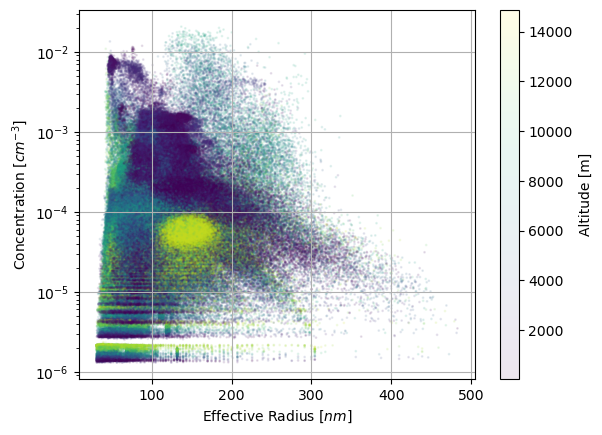

In [52]:
plt.figure()
plt.scatter(1e9*r_eff_arr,number_conc_arr*1e-6,s=1,alpha=0.1,c=aircraft_vars_arr_dct['GGALT'])
# plt.xscale('log')
plt.yscale('log')
plt.grid(visible=True)
plt.xlabel("Effective Radius [$nm$]")
plt.ylabel("Concentration [$cm^{-3}$]")
plt.colorbar(label='Altitude [m]')

In [66]:
beta_precision = 0.01
alpha_precision = 0.1
percentile_arr = np.array([0.01,0.05,0.1,0.5,0.9,0.95,0.99])
sample_count = 5000

beta_noise_floor = 1e-8  # restrict analysis to instances of backscatter larger than this
beta_noise_floor_idx = 1 # index to channel used for setting the noise floor

conc_log_std_lst = []
conc_log_mean_lst = []
beta_coef_set_lst = []
alpha_coef_set_lst = []
cum_percentile_lst = []
cum_case_cnt_lst = []

r_mean_mean_lst = []
r_mean_std_lst = []


# TODO:  Rather than sample the data points, we should sample the overall distribution space.
# could estimate a multi-variate gaussian distribution (or multiple-multi-variate gaussians) to fit
# the observed points and define the sampling space from that

# # randomly sample a sample_count points
pt_idx_lst = np.random.choice(np.arange(number_conc_arr.size)[np.where(~np.isnan(number_conc_arr)&(number_conc_arr>0)&(beta_coef_arr[beta_noise_floor_idx,:]>beta_noise_floor))],size=sample_count,replace=False)
# pt_idx_lst = np.random.choice(np.arange(number_conc_arr.size)[np.where(~np.isnan(number_conc_arr)&(number_conc_arr>0))],size=sample_count,replace=False)
# use all valid points
# pt_idx_lst = np.arange(number_conc_arr.size)[np.where(~np.isnan(number_conc_arr)&(number_conc_arr>0))]

for iter_idx,pt_idx in enumerate(pt_idx_lst):
    h_conc_beta_lst = []
    h_conc_alpha_lst = []
    cum_where_arg = np.ones(beta_coef_arr[idx,:].size,dtype=bool)
    for idx in range(len(wavelen_lst)):
        # backscatter
        idx_backscat = np.where(np.abs(np.log10(beta_coef_arr[idx,:])-np.log10(beta_coef_arr[idx,pt_idx])) < beta_precision)
        cum_where_arg = cum_where_arg & (np.abs(np.log10(beta_coef_arr[idx,:])-np.log10(beta_coef_arr[idx,pt_idx])) < beta_precision)

        # extinction
        idx_extinct = np.where(np.abs(np.log10(alpha_coef_arr[idx,:])-np.log10(alpha_coef_arr[idx,pt_idx])) < alpha_precision)
        # cum_where_arg = cum_where_arg & (np.abs(np.log10(alpha_coef_arr[idx,:])-np.log10(alpha_coef_arr[idx,pt_idx])) < alpha_precision)
        
        conc_set_beta = number_conc_arr[idx_backscat]
        conc_set_alpha = number_conc_arr[idx_extinct]
        
        h_conc_beta = np.histogram(conc_set_beta,bins=np.logspace(0,4))
        h_conc_alpha = np.histogram(conc_set_alpha,bins=np.logspace(0,4))
        h_conc_beta_lst.append(h_conc_beta)
        h_conc_alpha_lst.append(h_conc_alpha)
        
    total_case_count = np.sum(cum_where_arg)
    beta_coef_set_lst.append(beta_coef_arr[:,pt_idx])
    alpha_coef_set_lst.append(alpha_coef_arr[:,pt_idx])
    conc_set_total = number_conc_arr[np.where(cum_where_arg)]
    conc_log_std = np.std(np.log(conc_set_total))
    conc_log_mean = np.mean(np.log(conc_set_total))
    r_mean_set_total = mean_r_arr[np.where(conc_set_total)]
    r_mean_std = np.std(np.log(r_mean_set_total))
    r_mean_mean = np.mean(np.log(r_mean_set_total))
    
    h_total = np.histogram(conc_set_total,bins=np.logspace(0,4))
    h_total_cum = np.cumsum(h_total[0]/np.sum(h_total[0]))
    h_percentile = np.interp(percentile_arr,h_total_cum,h_total[1][1:])
    conc_log_std_lst.append(conc_log_std)
    conc_log_mean_lst.append(conc_log_mean)
    cum_percentile_lst.append(h_percentile)
    cum_case_cnt_lst.append(total_case_count)
    r_mean_mean_lst.append(r_mean_mean)
    r_mean_std_lst.append(r_mean_std)

/tmp/ipykernel_645262/377929856.py:62: RuntimeWarning: invalid value encountered in divide
  h_total_cum = np.cumsum(h_total[0]/np.sum(h_total[0]))


In [67]:
cum_percentile_arr = np.stack(cum_percentile_lst,axis=1)

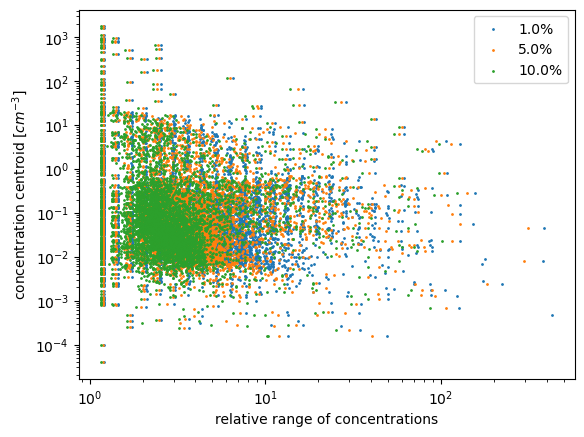

In [68]:
plt.figure()
# for proj in project_dct:
#     proj_idx = np.where(
#     plt.scatter(
plt.scatter(cum_percentile_arr[-1,:]/cum_percentile_arr[0,:],10**np.array(conc_log_mean_lst)*1e-6,s=1,label=f"{100*percentile_arr[0]}%")
plt.scatter(cum_percentile_arr[-2,:]/cum_percentile_arr[1,:],10**np.array(conc_log_mean_lst)*1e-6,s=1,label=f"{100*percentile_arr[1]}%")
plt.scatter(cum_percentile_arr[-3,:]/cum_percentile_arr[2,:],10**np.array(conc_log_mean_lst)*1e-6,s=1,label=f"{100*percentile_arr[2]}%")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("relative range of concentrations")
plt.ylabel("concentration centroid [$cm^{-3}$]")
plt.legend()

Text(0, 0.5, '$\\mu$ [$cm^{-3}$]')

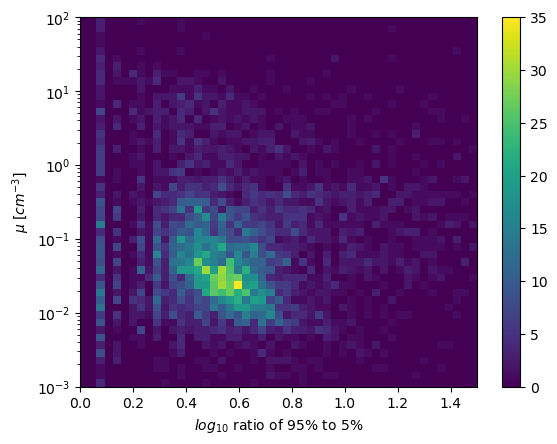

In [72]:
hist_m_s = np.histogram2d(np.log10(cum_percentile_arr[-2,:]/cum_percentile_arr[1,:]),10**np.array(conc_log_mean_lst)*1e-6,bins=(np.linspace(0,1.5,50),np.logspace(-3,2,50)))
plt.figure()
plt.pcolormesh(hist_m_s[1],hist_m_s[2],hist_m_s[0].T)
plt.colorbar()
plt.yscale('log')
plt.xlabel("$log_{10}$ ratio of 95% to 5%")
plt.ylabel("$\mu$ [$cm^{-3}$]")

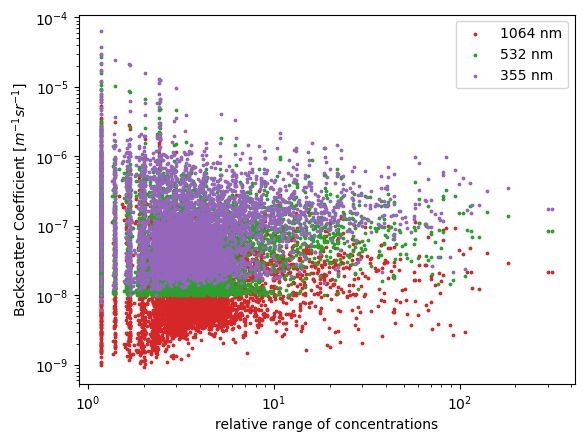

In [69]:
# idx=1
plt.figure()
# for proj in project_dct:
#     proj_idx = np.where(
#     plt.scatter(
for idx in range(len(wavelen_color)):
    plt.scatter(cum_percentile_arr[-2,:]/cum_percentile_arr[1,:],np.stack(beta_coef_set_lst)[:,idx],s=3,c=wavelen_color[idx],label=f"{int(wavelen_lst[idx]*1e9)} nm")
# plt.scatter(cum_percentile_arr[-2,:]/cum_percentile_arr[1,:],10**np.array(conc_log_mean_lst)*1e-6,s=1,label=f"{100*percentile_arr[1]}%")
# plt.scatter(cum_percentile_arr[-3,:]/cum_percentile_arr[2,:],10**np.array(conc_log_mean_lst)*1e-6,s=1,label=f"{100*percentile_arr[2]}%")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("relative range of concentrations")
plt.ylabel("Backscatter Coefficient [$m^{-1} sr^{-1}$]")
plt.legend()

In [59]:
np.stack(beta_coef_set_lst).shape

(5000, 3)

Text(0, 0.5, 'number of data points in analysis')

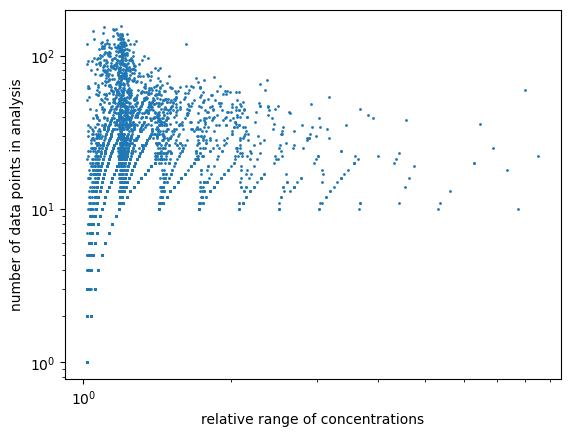

In [50]:
plt.figure()
# for proj in project_dct:
#     proj_idx = np.where(
#     plt.scatter(
plt.scatter(cum_percentile_arr[2,:]/cum_percentile_arr[0,:],np.array(cum_case_cnt_lst),s=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("relative range of concentrations")
plt.ylabel("number of data points in analysis")

In [19]:
beta_coef_set_arr = np.stack(beta_coef_set_lst)

In [20]:
beta_coef_set_arr.shape

(5000, 2)

Text(0.5, 0, 'Backscatter Coefficient [$m^{-1}sr^{-1}$]')

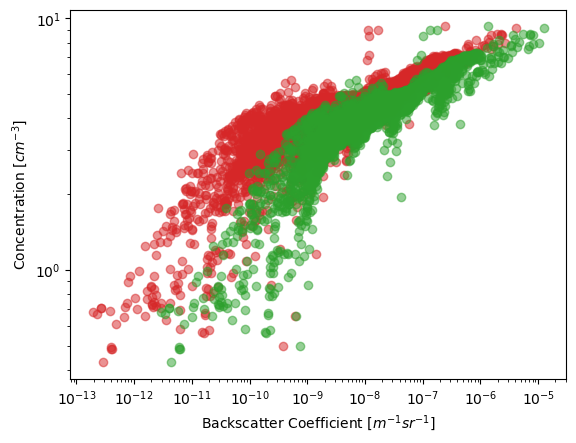

In [27]:
plt.figure()
plt.scatter(beta_coef_set_arr[:,0],conc_log_mean_lst,c='tab:red',alpha=0.5)
plt.scatter(beta_coef_set_arr[:,1],conc_log_mean_lst,c='tab:green',alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.ylabel("Concentration [$cm^{-3}$]")
plt.xlabel("Backscatter Coefficient [$m^{-1}sr^{-1}$]")


In [16]:
# fig,ax = plt.subplots(1,1,)
# hist_perc = np.histogram(cum_percentile_arr[2,:]/cum_percentile_arr[0,:],bins=np.logspace(0,2,100))
# ax.barh(hist_perc[1][:-1],hist_perc[0].astype(float)/cum_percentile_arr.shape[1],
#         align='edge',height=np.diff(hist_perc[1]),alpha=0.5,color='tab:blue',label='Total')
# # ax.set_xscale('log')
# ax.set_ylim([0,0.1])

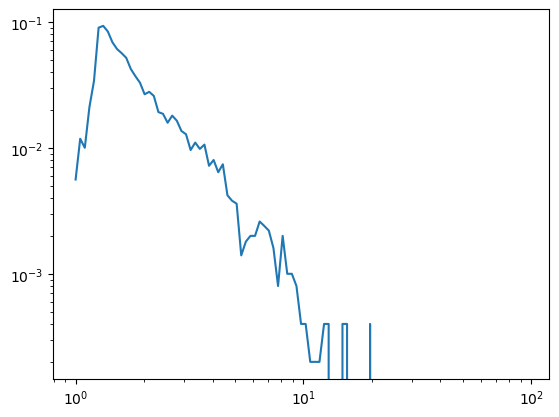

In [18]:
hist_perc = np.histogram(cum_percentile_arr[2,:]/cum_percentile_arr[0,:],bins=np.logspace(0,2,100))
plt.figure()
plt.plot(hist_perc[1][:-1],hist_perc[0].astype(float)/cum_percentile_arr.shape[1])
plt.xscale('log')
plt.yscale('log')